# Proposed E-VGG19 Model — Enhanced VGG19 with Hybrid Classifiers
### Skin Cancer Detection ML Project | Colab-Style Notebook
---
> **Paper:** *Performance evaluation of E-VGG19 model for skin lesion detection*
> **Journal:** Heliyon, 2024 — DOI: 10.1016/j.heliyon.2024.e31488

---
## E-VGG19 Architectural Modifications vs Standard VGG19

| Block | Standard VGG19 | E-VGG19 |
|-------|---------------|----------|
| Block 1 | 2 Conv + Pool | 2 Conv + Pool + **BatchNorm** |
| Block 2 | 2 Conv + Pool | 2 Conv + Pool + **BatchNorm** |
| Block 3 | **4** Conv + Pool | **3** Conv + Pool + **BatchNorm** |
| Block 4 | 4 Conv + Pool | 4 Conv + Pool + **BatchNorm** |
| Block 5 | 4 Conv + Pool | 4 Conv + Pool + **BatchNorm** |
| Head | Dense(4096)×2 + Softmax | **GlobalAveragePooling2D** |

**Key changes:**
1. Remove 1 Conv layer from Block 3 (3 instead of 4)
2. Add BatchNormalization after each MaxPooling
3. Replace Dense top with GlobalAveragePooling2D
4. Use as feature extractor (512-dim vector) for SVM / LR / RF classifiers

---
## Sections
1. Setup and Imports
2. Load and Preprocess Data
3. Build E-VGG19 Architecture
4. Feature Extraction with E-VGG19
5. Train-Test Split and Scaling
6. Hybrid Classifiers: SVM, Logistic Regression, Random Forest
7. Confusion Matrices
8. E-VGG19 End-to-End Binary Classifier (Fine-Tuned)
9. Final Results Comparison Table


---
## 1. Setup and Imports


In [3]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

print(f'TF: {tf.__version__} | GPU: {bool(tf.config.list_physical_devices("GPU"))}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f'Enabled dynamic memory growth for {gpu.name}')
        except RuntimeError as e:
            print(e)


TF: 2.21.0 | GPU: True
Enabled dynamic memory growth for /physical_device:GPU:0


---
## 2. Load and Preprocess Data


In [4]:
import os
import glob
import pandas as pd

# Detect if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Running in Google Colab!')
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Metadata path
    METADATA_PATH = 'HAM10000_metadata.csv'
    if not os.path.exists(METADATA_PATH):
        METADATA_PATH = '/content/HAM10000_metadata.csv'
    
    IMAGES_DIR = '/content/drive/MyDrive'
else:
    # Local path resolution
    wsl_path = os.path.expanduser('~/data/HAM10000_metadata.csv')
    if os.path.exists(wsl_path):
        METADATA_PATH = wsl_path
        IMAGES_DIR = os.path.expanduser('~/data')
    elif os.path.exists('data/HAM10000_metadata.csv'):
        METADATA_PATH = 'data/HAM10000_metadata.csv'
        IMAGES_DIR = 'data'
    elif os.path.exists('../data/HAM10000_metadata.csv'):
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR = '../data'
    else:
        METADATA_PATH = '../data/HAM10000_metadata.csv'
        IMAGES_DIR = '../data'

print(f'Metadata Path: {METADATA_PATH}')
print(f'Images Directory: {IMAGES_DIR}')

df = pd.read_csv(METADATA_PATH)

image_paths = []
part1_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_1')
part2_path = os.path.join(IMAGES_DIR, 'HAM10000_images_part_2')

if os.path.exists(part1_path):
    image_paths.extend(glob.glob(os.path.join(part1_path, '*.jpg')))
if os.path.exists(part2_path):
    image_paths.extend(glob.glob(os.path.join(part2_path, '*.jpg')))

if len(image_paths) == 0:
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '*.jpg')))

if len(image_paths) == 0:
    if IN_COLAB and IMAGES_DIR == '/content/drive/MyDrive':
        print('[WARNING] Scanning the entire Google Drive recursively might be very slow!')
    image_paths.extend(glob.glob(os.path.join(IMAGES_DIR, '**', '*.jpg'), recursive=True))

image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
df['path'] = df['image_id'].map(image_path_dict.get)
df = df.dropna(subset=['path']).reset_index(drop=True)

lesion_danger = {'nv': 0, 'mel': 1, 'bkl': 0, 'bcc': 1, 'akiec': 1, 'vasc': 0, 'df': 0}
df['target'] = df['dx'].map(lesion_danger)
df['class_str'] = df['target'].astype(str)

print(f'Total usable samples: {len(df)}')
print(df['target'].value_counts().to_string())


Metadata Path: /home/shan_ahmedshani/data/HAM10000_metadata.csv
Images Directory: /home/shan_ahmedshani/data
Total usable samples: 10015
target
0    8061
1    1954


---
## 3. Build E-VGG19 Architecture


In [5]:
def build_evgg19(input_shape=(224, 224, 3), freeze_backbone=True):
    """
    E-VGG19 (Enhanced VGG19) as described in:
    Kandhro et al., Heliyon 2024, DOI: 10.1016/j.heliyon.2024.e31488

    Modifications vs standard VGG19:
      - Block 3: 3 Conv layers (instead of 4)
      - BatchNormalization after each MaxPooling
      - GlobalAveragePooling2D as feature extractor head
    """
    inputs = Input(shape=input_shape)

    # ── Block 1 ────────────────────────────────────────────────────────
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='b1_conv1')(inputs)
    x = Conv2D(64, (3,3), activation='relu', padding='same', name='b1_conv2')(x)
    x = MaxPooling2D((2,2), strides=(2,2), name='b1_pool')(x)
    x = BatchNormalization(name='b1_bn')(x)

    # ── Block 2 ────────────────────────────────────────────────────────
    x = Conv2D(128, (3,3), activation='relu', padding='same', name='b2_conv1')(x)
    x = Conv2D(128, (3,3), activation='relu', padding='same', name='b2_conv2')(x)
    x = MaxPooling2D((2,2), strides=(2,2), name='b2_pool')(x)
    x = BatchNormalization(name='b2_bn')(x)

    # ── Block 3: 3 Conv instead of 4 ───────────────────────────────────
    x = Conv2D(256, (3,3), activation='relu', padding='same', name='b3_conv1')(x)
    x = Conv2D(256, (3,3), activation='relu', padding='same', name='b3_conv2')(x)
    x = Conv2D(256, (3,3), activation='relu', padding='same', name='b3_conv3')(x)
    x = MaxPooling2D((2,2), strides=(2,2), name='b3_pool')(x)
    x = BatchNormalization(name='b3_bn')(x)

    # ── Block 4 ────────────────────────────────────────────────────────
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b4_conv1')(x)
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b4_conv2')(x)
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b4_conv3')(x)
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b4_conv4')(x)
    x = MaxPooling2D((2,2), strides=(2,2), name='b4_pool')(x)
    x = BatchNormalization(name='b4_bn')(x)

    # ── Block 5 ────────────────────────────────────────────────────────
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b5_conv1')(x)
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b5_conv2')(x)
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b5_conv3')(x)
    x = Conv2D(512, (3,3), activation='relu', padding='same', name='b5_conv4')(x)
    x = MaxPooling2D((2,2), strides=(2,2), name='b5_pool')(x)
    x = BatchNormalization(name='b5_bn')(x)

    # ── Feature Head: GAP (replaces Dense head) ─────────────────────────
    out = GlobalAveragePooling2D(name='gap')(x)

    model = Model(inputs=inputs, outputs=out, name='E-VGG19')

    # ── Transfer weights from VGG19 where layer names match ────────────
    vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    vgg19_layer_names = {l.name: l for l in vgg19_base.layers}

    transferred = 0
    name_map = {
        'b1_conv1': 'block1_conv1', 'b1_conv2': 'block1_conv2',
        'b2_conv1': 'block2_conv1', 'b2_conv2': 'block2_conv2',
        'b3_conv1': 'block3_conv1', 'b3_conv2': 'block3_conv2', 'b3_conv3': 'block3_conv3',
        'b4_conv1': 'block4_conv1', 'b4_conv2': 'block4_conv2',
        'b4_conv3': 'block4_conv3', 'b4_conv4': 'block4_conv4',
        'b5_conv1': 'block5_conv1', 'b5_conv2': 'block5_conv2',
        'b5_conv3': 'block5_conv3', 'b5_conv4': 'block5_conv4',
    }
    for my_name, vgg_name in name_map.items():
        try:
            model.get_layer(my_name).set_weights(
                vgg19_base.get_layer(vgg_name).get_weights()
            )
            transferred += 1
        except Exception:
            pass

    # Freeze convolutional layers if requested
    for layer in model.layers:
        if isinstance(layer, Conv2D):
            layer.trainable = not freeze_backbone

    print(f'E-VGG19 built — {len(model.layers)} layers, '
          f'{model.count_params():,} total params')
    print(f'Weight blocks transferred from VGG19: {transferred}')
    return model


evgg19_extractor = build_evgg19()
evgg19_extractor.summary()


E-VGG19 built — 27 layers, 19,440,192 total params
Weight blocks transferred from VGG19: 15


Model: "E-VGG19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn (BatchNormalization)      │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn (BatchNormalization)      │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv3 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pool (MaxPooling2D)          │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn (BatchNormalization)      │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv1 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv2 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv3 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_conv4 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_pool (MaxPooling2D)          │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b4_bn (BatchNormalization)      │ (None, 14, 14, 512)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv1 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv2 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv3 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_conv4 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b5_pool (MaxPooling2D)          │ (None, 7, 7, 512)      │             

 Total params: 19,440,192 (74.16 MB)

 Trainable params: 2,944 (11.50 KB)

 Non-trainable params: 19,437,248 (74.15 MB)

---
## 4. Feature Extraction with E-VGG19
We extract **512-dimensional feature vectors** for each image.
Using **2000 samples** for demonstration (increase for full training).


In [6]:
N_SAMPLES = 2000
IMG_SIZE = (224, 224)

sub_df = df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)

features = []
labels = []

print(f'Extracting E-VGG19 features for {N_SAMPLES} images...')
for idx, row in sub_df.iterrows():
    if idx % 400 == 0:
        print(f' {idx}/{N_SAMPLES} processed...')
    try:
        img = load_img(row['path'], target_size=IMG_SIZE)
        arr = img_to_array(img) / 255.0
        arr = np.expand_dims(arr, axis=0)
        feat = evgg19_extractor.predict(arr, verbose=0)
        features.append(feat.ravel())
        labels.append(row['target'])
    except Exception as e:
        print(f' Error: {e}')

X_feat = np.array(features)
y_lbl = np.array(labels)
print(f'\n Feature matrix: {X_feat.shape} (512-dim per image)')


Extracting E-VGG19 features for 2000 images...
 0/2000 processed...
 400/2000 processed...
 800/2000 processed...
 1200/2000 processed...
 1600/2000 processed...

 Feature matrix: (2000, 512) (512-dim per image)


---
## 5. Train-Test Split and Feature Scaling


In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_feat, y_lbl, test_size=0.2, random_state=42, stratify=y_lbl
)
print(f'Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}')

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)
print(' StandardScaler applied')


Train: 1600 | Test: 400
 StandardScaler applied


---
## 6. Hybrid Classifiers on E-VGG19 Features


In [8]:
hybrid_results = {}

def train_hybrid(name, clf):
    print(f'▶ Training {name}...')
    clf.fit(X_tr_sc, y_tr)
    preds = clf.predict(X_te_sc)
    acc = accuracy_score(y_te, preds)
    rep = classification_report(y_te, preds, target_names=['Benign','Malignant'],
                                 output_dict=True, zero_division=0)
    hybrid_results[name] = {'acc': acc, 'rep': rep, 'preds': preds, 'clf': clf}
    print(f' Accuracy: {acc:.4f}')
    print(classification_report(y_te, preds, target_names=['Benign','Malignant'], zero_division=0))
    print('-' * 55)

print('=' * 55)
print(' E-VGG19 HYBRID CLASSIFICATION')
print('=' * 55)

train_hybrid('E-VGG19 + SVM (RBF)', SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True))
train_hybrid('E-VGG19 + Logistic Regression', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced'))
train_hybrid('E-VGG19 + Random Forest', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42))


 E-VGG19 HYBRID CLASSIFICATION
▶ Training E-VGG19 + SVM (RBF)...
 Accuracy: 0.7550
              precision    recall  f1-score   support

      Benign       0.94      0.75      0.83       323
   Malignant       0.43      0.79      0.55        77

    accuracy                           0.76       400
   macro avg       0.68      0.77      0.69       400
weighted avg       0.84      0.76      0.78       400

-------------------------------------------------------
▶ Training E-VGG19 + Logistic Regression...
 Accuracy: 0.7775
              precision    recall  f1-score   support

      Benign       0.91      0.81      0.85       323
   Malignant       0.45      0.65      0.53        77

    accuracy                           0.78       400
   macro avg       0.68      0.73      0.69       400
weighted avg       0.82      0.78      0.79       400

-------------------------------------------------------
▶ Training E-VGG19 + Random Forest...
 Accuracy: 0.8300
              precision    recall

---
## 7. Confusion Matrices for Hybrid Classifiers


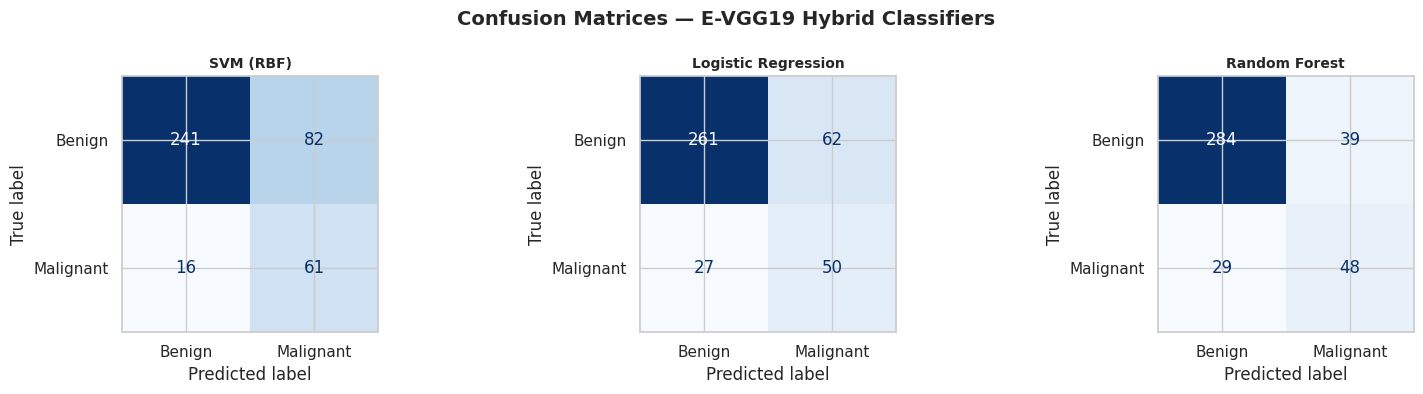

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, r) in enumerate(hybrid_results.items()):
    cm = confusion_matrix(y_te, r['preds'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign','Malignant'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name.replace('E-VGG19 + ', ''), fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — E-VGG19 Hybrid Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8. E-VGG19 End-to-End Binary Classifier (Fine-Tuned)
We add a binary classification head on top of E-VGG19 and fine-tune.


In [10]:
def build_evgg19_classifier(input_shape=(224, 224, 3), fine_tune=True):
    """E-VGG19 with binary classification head."""
    # Build the extractor but keep backbone trainable so we can selectively freeze
    extractor = build_evgg19(input_shape, freeze_backbone=not fine_tune)

    if fine_tune:
        # Freeze blocks 1, 2, 3 and keep blocks 4, 5 trainable to learn dermoscopic features
        for layer in extractor.layers:
            if isinstance(layer, Conv2D):
                if layer.name.startswith(('b1_', 'b2_', 'b3_')):
                    layer.trainable = False
                else:
                    layer.trainable = True

    # Add classification head
    x = extractor.output
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=extractor.input, outputs=out, name='E-VGG19-Classifier')
    # Use lower learning rate for fine-tuning to protect pre-trained lower-block features
    lr = 1e-5 if fine_tune else 1e-4
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

evgg19_clf = build_evgg19_classifier()
print(f'E-VGG19 Classifier — trainable params: {sum(p.numpy().size for p in evgg19_clf.trainable_weights):,}')

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    horizontal_flip=True, vertical_flip=True, zoom_range=0.1
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_df_e, test_df_e = train_test_split(df, test_size=0.15, random_state=42, stratify=df['target'])
train_df_e, val_df_e = train_test_split(train_df_e, test_size=0.15, random_state=42, stratify=train_df_e['target'])

gen_train = train_datagen.flow_from_dataframe(
    train_df_e, x_col='path', y_col='class_str',
    target_size=(224,224), class_mode='binary', batch_size=16, shuffle=True
)
gen_val = val_datagen.flow_from_dataframe(
    val_df_e, x_col='path', y_col='class_str',
    target_size=(224,224), class_mode='binary', batch_size=16, shuffle=False
)
gen_test = val_datagen.flow_from_dataframe(
    test_df_e, x_col='path', y_col='class_str',
    target_size=(224,224), class_mode='binary', batch_size=16, shuffle=False
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df_e['target']),
    y=train_df_e['target'].values
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Applying Class Weights: {class_weight_dict}')

history_evgg19 = evgg19_clf.fit(
    gen_train, epochs=20, validation_data=gen_val,
    callbacks=callbacks, verbose=1,
    class_weight=class_weight_dict
)


E-VGG19 built — 27 layers, 19,440,192 total params
Weight blocks transferred from VGG19: 15
E-VGG19 Classifier — trainable params: 18,097,025
Found 7235 validated image filenames belonging to 2 classes.
Found 1277 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.
Applying Class Weights: {0: np.float64(0.6212433453546282), 1: np.float64(2.561968838526912)}
Epoch 1/20


E0000 00:00:1780853691.934882   15280 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780853697.007767   15280 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


410/453 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.6525 - loss: 0.7361

E0000 00:00:1780853798.025056   15278 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1780853799.732992   15278 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


453/453 ━━━━━━━━━━━━━━━━━━━━ 155s 291ms/step - accuracy: 0.6766 - loss: 0.6269 - val_accuracy: 0.7236 - val_loss: 0.4949 - learning_rate: 1.0000e-05
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 105s 231ms/step - accuracy: 0.7070 - loss: 0.5308 - val_accuracy: 0.8003 - val_loss: 0.4103 - learning_rate: 1.0000e-05
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 108s 237ms/step - accuracy: 0.7179 - loss: 0.5156 - val_accuracy: 0.8168 - val_loss: 0.3706 - learning_rate: 1.0000e-05
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 103s 227ms/step - accuracy: 0.7429 - loss: 0.4808 - val_accuracy: 0.7009 - val_loss: 0.6003 - learning_rate: 1.0000e-05
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 102s 225ms/step - accuracy: 0.7455 - loss: 0.4760 - val_accuracy: 0.7792 - val_loss: 0.4105 - learning_rate: 1.0000e-05
Epoch 6/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.7613 - loss: 0.4488
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
453/453 ━━━━━━━━━━━━━━━━━━━━ 102s 225ms/step - 


E-VGG19 End-to-End Accuracy: 0.8057 (Threshold: 0.35)
              precision    recall  f1-score   support

      Benign       0.96      0.79      0.87      1210
   Malignant       0.50      0.86      0.63       293

    accuracy                           0.81      1503
   macro avg       0.73      0.83      0.75      1503
weighted avg       0.87      0.81      0.82      1503



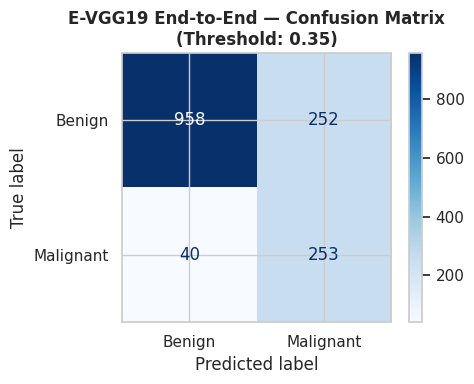

In [11]:
# Evaluate end-to-end E-VGG19 with custom threshold to balance precision/recall
gen_test.reset()
y_prob_e2e = evgg19_clf.predict(gen_test, verbose=0).ravel()
threshold = 0.35
y_pred_e2e = (y_prob_e2e >= threshold).astype(int)
y_true_e2e = gen_test.classes

acc_e2e = accuracy_score(y_true_e2e, y_pred_e2e)
rep_e2e = classification_report(y_true_e2e, y_pred_e2e,
                                  target_names=['Benign','Malignant'],
                                  output_dict=True, zero_division=0)
print(f'\nE-VGG19 End-to-End Accuracy: {acc_e2e:.4f} (Threshold: {threshold})')
print(classification_report(y_true_e2e, y_pred_e2e, target_names=['Benign','Malignant'], zero_division=0))

# Confusion matrix
cm_e2e = confusion_matrix(y_true_e2e, y_pred_e2e)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_e2e, display_labels=['Benign','Malignant']).plot(ax=ax, cmap='Blues')
ax.set_title(f'E-VGG19 End-to-End — Confusion Matrix\n(Threshold: {threshold})', fontweight='bold')
plt.tight_layout()
plt.show()


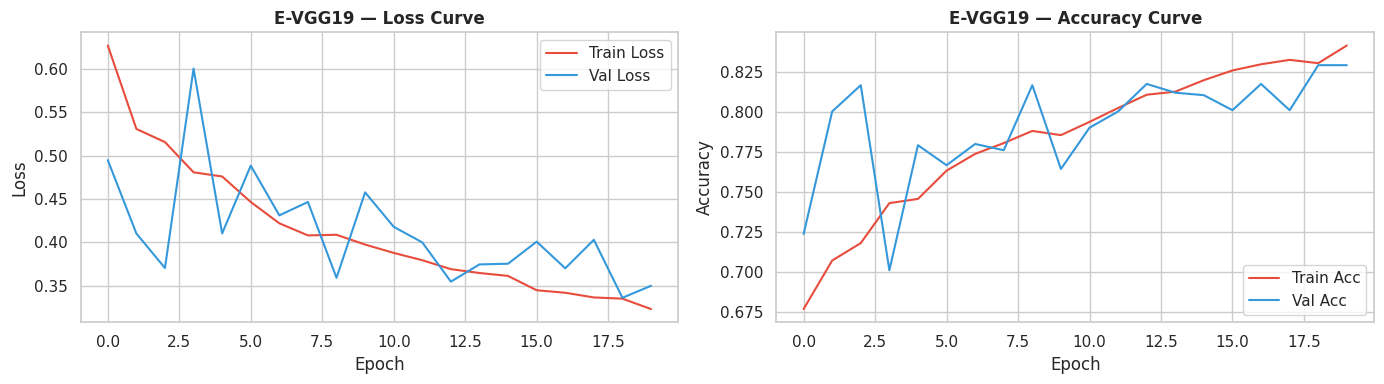

In [12]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_evgg19.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(history_evgg19.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('E-VGG19 — Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history_evgg19.history['accuracy'], label='Train Acc', color='#e74c3c')
axes[1].plot(history_evgg19.history['val_accuracy'], label='Val Acc', color='#3498db')
axes[1].set_title('E-VGG19 — Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.show()


---
## 9. Final Results — Complete Comparison Table


In [13]:
print('=' * 70)
print(' FINAL RESULTS — E-VGG19 HYBRID vs END-TO-END')
print('=' * 70)

final_rows = []

# Hybrid models
for name, r in hybrid_results.items():
    rep = r['rep']
    final_rows.append({
        'Model' : name,
        'Accuracy' : round(r['acc'], 4),
        'B_Precision' : round(rep['Benign']['precision'], 4),
        'B_Recall' : round(rep['Benign']['recall'], 4),
        'B_F1' : round(rep['Benign']['f1-score'], 4),
        'M_Precision' : round(rep['Malignant']['precision'], 4),
        'M_Recall' : round(rep['Malignant']['recall'], 4),
        'M_F1' : round(rep['Malignant']['f1-score'], 4),
    })

# End-to-End
final_rows.append({
    'Model' : 'E-VGG19 (End-to-End)',
    'Accuracy' : round(acc_e2e, 4),
    'B_Precision' : round(rep_e2e['Benign']['precision'], 4),
    'B_Recall' : round(rep_e2e['Benign']['recall'], 4),
    'B_F1' : round(rep_e2e['Benign']['f1-score'], 4),
    'M_Precision' : round(rep_e2e['Malignant']['precision'], 4),
    'M_Recall' : round(rep_e2e['Malignant']['recall'], 4),
    'M_F1' : round(rep_e2e['Malignant']['f1-score'], 4),
})

final_df = pd.DataFrame(final_rows).set_index('Model')
print(final_df.to_string())
final_df


 FINAL RESULTS — E-VGG19 HYBRID vs END-TO-END
                               Accuracy  B_Precision  B_Recall    B_F1  M_Precision  M_Recall    M_F1
Model                                                                                                
E-VGG19 + SVM (RBF)              0.7550       0.9377    0.7461  0.8310       0.4266    0.7922  0.5545
E-VGG19 + Logistic Regression    0.7775       0.9062    0.8080  0.8543       0.4464    0.6494  0.5291
E-VGG19 + Random Forest          0.8300       0.9073    0.8793  0.8931       0.5517    0.6234  0.5854
E-VGG19 (End-to-End)             0.8057       0.9599    0.7917  0.8678       0.5010    0.8635  0.6341


,Accuracy,B_Precision,B_Recall,B_F1,M_Precision,M_Recall,M_F1
Model,,,,,,,
E-VGG19 + SVM (RBF),0.7550,0.9377,0.7461,0.8310,0.4266,0.7922,0.5545
E-VGG19 + Logistic Regression,0.7775,0.9062,0.8080,0.8543,0.4464,0.6494,0.5291
E-VGG19 + Random Forest,0.8300,0.9073,0.8793,0.8931,0.5517,0.6234,0.5854
E-VGG19 (End-to-End),0.8057,0.9599,0.7917,0.8678,0.5010,0.8635,0.6341


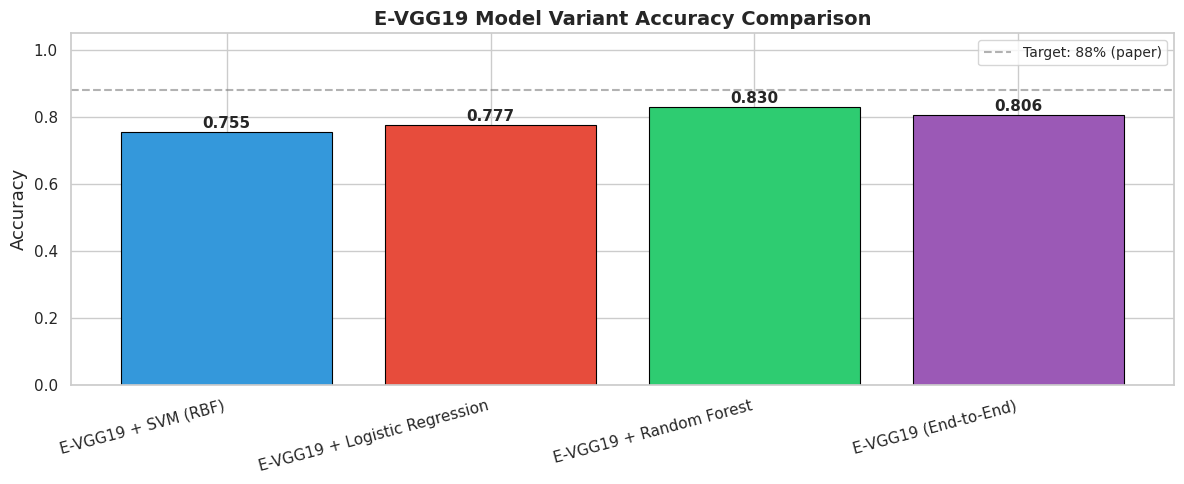


 Best model: E-VGG19 + Random Forest with accuracy 0.8300


In [14]:
# Bar chart: Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.bar(final_df.index, final_df['Accuracy'],
              color=colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, final_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('E-VGG19 Model Variant Accuracy Comparison', fontweight='bold', fontsize=14)
ax.axhline(0.88, color='gray', linestyle='--', alpha=0.6, label='Target: 88% (paper)')
ax.legend(fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

best = final_df['Accuracy'].idxmax()
print(f'\n Best model: {best} with accuracy {final_df.loc[best, "Accuracy"]:.4f}')
